# GRA: lion + GR + rosenbrock

project = ```GRA```, host = ```mach```, device = ```cuda:2```

## Goals:

Test these Lion extensions:

1. **relativistic**
2. **general relativistic**

Test on `rosenbrock` simulation

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Main

In [3]:
from optimzers import *
from test.test import *

## brick wall test

In [4]:
def brick_wall_loss(x):
    # Gentle slope for x > 0, vertical wall for x <= 0
    if x > 0:
        return 0.5 * x**2
    else:
        return 1000.0 * x**2

In [5]:
import torch
import matplotlib.pyplot as plt

# --- 1. Define the "Brick Wall" Loss ---


# --- 2. Simulation Harness ---
def run_simulation(optimizer_class, kwargs, label, color):
    # Initialize far away to build momentum
    x = torch.tensor([2.0], requires_grad=True)
    
    # We must instantiate the optimizer
    # (Assuming RelativisticLion class is defined as in previous turn)
    opt = optimizer_class([x], **kwargs)
    
    path = []
    grads = []
    
    # Run for 50 steps
    for t in range(200):
        path.append(x.item())
        
        loss = brick_wall_loss(x)
        opt.zero_grad()
        loss.backward()
        
        # Store gradient for visualization
        grads.append(x.grad.item())
        
        # Clip gradient for Adam/Vanilla to prevent NaN if they explode too hard
        # (We don't clip for Relativistic Lion to prove a point)
        if "Lion" not in label or "Vanilla" in label:
             torch.nn.utils.clip_grad_norm_([x], 100.0)
             
        opt.step()
        
        # Stop if diverged
        if abs(x.item()) > 100:
            break
            
    return path, grads

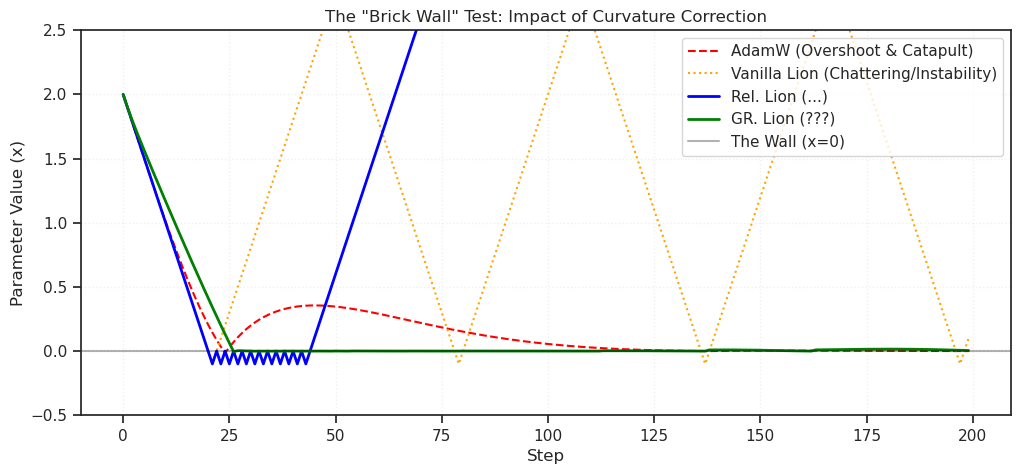

In [36]:
# --- 3. Run Comparisons ---
plt.figure(figsize=(12, 5))

# A. AdamW (Baseline)
# Often overshoots walls because variance adaptation is slow to react to sharp spikes
path_adam, _ = run_simulation(torch.optim.AdamW, 
                              {'lr': 0.1}, "AdamW", "red")
plt.plot(path_adam, label='AdamW (Overshoot & Catapult)', color='red', linestyle='--')

# B. Vanilla Lion (Massless)
# Builds momentum, hits wall, sign flip + huge gradient = instability
path_lion, _ = run_simulation(Lion, {'lr': 0.1}, "Vanilla Lion", "orange")
plt.plot(path_lion, label='Vanilla Lion (Chattering/Instability)', color='orange', linestyle=':')

# C. Relativistic Lion (Curvature Corrected)
# The "Smart Brake"
# High kappa (e.g., 1.0) means strong braking on gradient changes
path_rel, _ = run_simulation(RelativisticLion, 
                             {'lr': 0.1, 'mass': 1, 'use_curvature': True, 'betas':(0.9, 0.99)}, 
                             "Rel. Lion (Curvature)", "blue")
plt.plot(path_rel, label='Rel. Lion (...)', color='blue', linewidth=2)

path_fins, _ = run_simulation(GeneralRelativisticLion, 
                             {'lr': 0.1, 'mass': 1, 'gamma': 10,
                              'beta_gravity': 0.9, 'betas':(0.9, 0.99)}, 
                             "GR. Lion (???)", "green")
plt.plot(path_fins, label='GR. Lion (???)', color='green', linewidth=2)

# path_grlion, _ = run_simulation(GeneralRelativisticLion, 
#                              {'lr': 0.1, 'mass': 1000, 'gamma': 10, 'use_brake': True, 'betas':(0.9, 0.99)}, 
#                              "Relativistic Lion (Curvature)", "green")
# plt.plot(path_grlion, label='General Relativistic Lion (???)', color='green', linewidth=2)

# --- 4. Plotting ---
plt.axhline(0, color='black', alpha=0.3, label='The Wall (x=0)')
plt.title('The "Brick Wall" Test: Impact of Curvature Correction')
plt.xlabel('Step')
plt.ylabel('Parameter Value (x)')
plt.ylim(-0.5, 2.5) # Focus on the impact zone
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

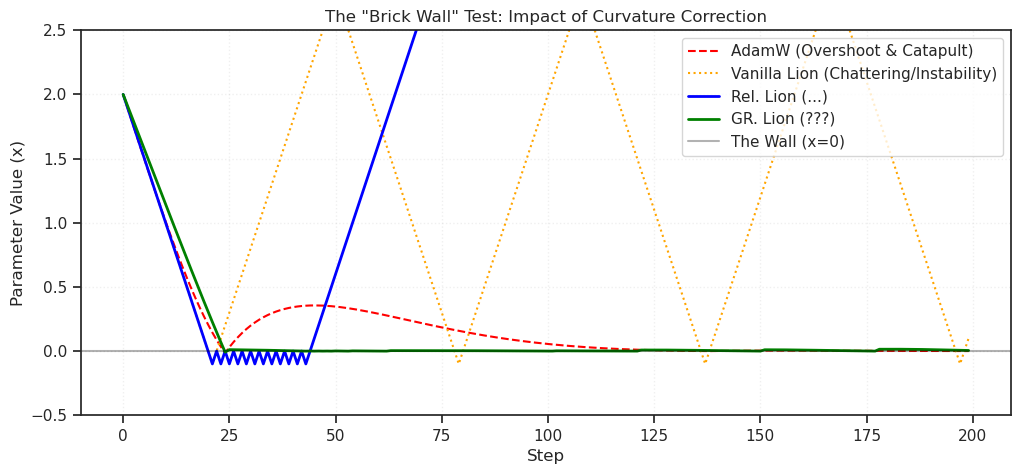

In [66]:
# --- 3. Run Comparisons ---
plt.figure(figsize=(12, 5))

# A. AdamW (Baseline)
# Often overshoots walls because variance adaptation is slow to react to sharp spikes
path_adam, _ = run_simulation(torch.optim.AdamW, 
                              {'lr': 0.1}, "AdamW", "red")
plt.plot(path_adam, label='AdamW (Overshoot & Catapult)', color='red', linestyle='--')

# B. Vanilla Lion (Massless)
# Builds momentum, hits wall, sign flip + huge gradient = instability
path_lion, _ = run_simulation(Lion, {'lr': 0.1}, "Vanilla Lion", "orange")
plt.plot(path_lion, label='Vanilla Lion (Chattering/Instability)', color='orange', linestyle=':')

# C. Relativistic Lion (Curvature Corrected)
# The "Smart Brake"
# High kappa (e.g., 1.0) means strong braking on gradient changes
path_rel, _ = run_simulation(RelativisticLion, 
                             {'lr': 0.1, 'mass': 1, 'use_curvature': True, 'betas':(0.9, 0.99)}, 
                             "Rel. Lion (Curvature)", "blue")
plt.plot(path_rel, label='Rel. Lion (...)', color='blue', linewidth=2)

path_fins, _ = run_simulation(GeneralRelativisticLion, 
                             {'lr': 0.1, 'mass': 120, 'gamma': 2,
                              'beta_gravity': 0.9, 'betas':(0.9, 0.99)}, 
                             "GR. Lion (???)", "green")
plt.plot(path_fins, label='GR. Lion (???)', color='green', linewidth=2)

# --- 4. Plotting ---
plt.axhline(0, color='black', alpha=0.3, label='The Wall (x=0)')
plt.title('The "Brick Wall" Test: Impact of Curvature Correction')
plt.xlabel('Step')
plt.ylabel('Parameter Value (x)')
plt.ylim(-0.5, 2.5) # Focus on the impact zone
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## need explanation

Wow, certain param combinations for the GR-Lion really good at absorbing that shock, but given the strong dependence on the combination of params, there must be something interesting going on.